Connected to Python (pygpu-env) (Python 3.11.8)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import cv2
import scipy.ndimage as nd

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class DifferentiableCanvasV3(nn.Module):
    def __init__(self, canvas_size=128):
        super().__init__()
        self.canvas_size = canvas_size
        y, x = torch.meshgrid(
            torch.linspace(0, 1, canvas_size, device=device),
            torch.linspace(0, 1, canvas_size, device=device),
            indexing='ij'
        )
        self.register_buffer('grid_x', x)
        self.register_buffer('grid_y', y)

    def draw_lines(self, stroke_params, global_blur):
        canvas = torch.ones((self.canvas_size, self.canvas_size), device=device)
        gx = self.grid_x
        gy = self.grid_y
        
        for i in range(stroke_params.shape[0]):
            x1, y1, x2, y2, thickness, opacity = stroke_params[i]
            
            ax, ay = x2 - x1, y2 - y1
            mag_sq = ax**2 + ay**2 + 1e-6
            
            px, py = gx - x1, gy - y1
            t = torch.clamp((px * ax + py * ay) / mag_sq, 0.0, 1.0)
            
            closest_x = x1 + t * ax
            closest_y = y1 + t * ay
            dist_sq = (gx - closest_x)**2 + (gy - closest_y)**2
            
            sigma = thickness * 0.02 + global_blur
            stroke = opacity * torch.exp(-dist_sq / (2 * sigma**2))
            
            canvas = canvas - stroke
            
        return torch.clamp(canvas, min=0.0, max=1.0)

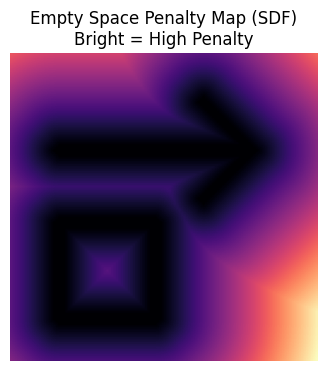

In [ ]:
CANVAS_SIZE = 128
target_img = np.ones((CANVAS_SIZE, CANVAS_SIZE), dtype=np.float32)

# 7-Segment Target
cv2.line(target_img, (20, 40), (100, 40), 0.0, 3)   
cv2.line(target_img, (100, 40), (80, 20), 0.0, 3)   
cv2.line(target_img, (100, 40), (80, 60), 0.0, 3)   
cv2.rectangle(target_img, (20, 70), (60, 110), 0.0, 3) 

target_tensor = torch.tensor(target_img, device=device)

# Create the Empty Space Penalty Map (Signed Distance Field)
# boolean mask where background (white) is True
background_mask = (target_img > 0.5) 
# Calculate distance from each True pixel to the nearest False (black) pixel
distance_field = nd.distance_transform_edt(background_mask)

# Normalize the distances so gradients don't explode
distance_field = distance_field / CANVAS_SIZE
sdf_tensor = torch.tensor(distance_field, device=device, dtype=torch.float32)

# Visualize the SDF Field
plt.figure(figsize=(4, 4))
plt.imshow(sdf_tensor.cpu().numpy(), cmap='magma')
plt.title("Empty Space Penalty Map (SDF)\nBright = High Penalty")
plt.axis('off')
plt.show()

In [ ]:
renderer = DifferentiableCanvasV3(canvas_size=CANVAS_SIZE)
NUM_STROKES = 15
raw_stroke_params = torch.randn((NUM_STROKES, 6), device=device, requires_grad=True)

optimizer = optim.Adam([raw_stroke_params], lr=0.05)

epochs = 1200
start_blur = 0.15
end_blur = 0.005

# Loss weights to balance the objectives
LAMBDA_SDF = 0.5    # Penalty for drawing in empty space
LAMBDA_LEN = 0.05   # Penalty for very long strokes
LAMBDA_OPAC = 0.005  # Penalty for using unnecessary strokes

print("Starting Geometric Edge Optimization...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    progress = epoch / epochs
    current_blur = start_blur * ((end_blur / start_blur) ** progress)
    scaled_params = torch.sigmoid(raw_stroke_params)
    rendered_canvas = renderer.draw_lines(scaled_params, global_blur=current_blur)
    
    # 1. Pixel-Wise Loss
    mse_loss = nn.MSELoss()(rendered_canvas, target_tensor)
    
    # 2. SDF Penalty (Annealed)
    # Give the strokes 400 epochs to travel across the canvas freely, 
    # then slowly turn on the forcefield to snap them cleanly into the lines.
    current_sdf_weight = 0.0
    if epoch > epochs // 3:
        ramp = min(1.0, (epoch - epochs // 3) / (epochs // 3))
        current_sdf_weight = LAMBDA_SDF * ramp
        
    ink_rendered = 1.0 - rendered_canvas
    sdf_loss = torch.mean(ink_rendered * sdf_tensor)
    
    # 3. Stroke Length Penalty
    dx = scaled_params[:, 2] - scaled_params[:, 0]
    dy = scaled_params[:, 3] - scaled_params[:, 1]
    lengths = torch.sqrt(dx**2 + dy**2 + 1e-6)
    length_loss = torch.mean(lengths * scaled_params[:, 5])
    
    # 4. Opacity Polarization & Penalty
    # Forces opacity to snap to either 1.0 (ink) or 0.0 (erased), destroying the "stacking" loophole.
    polarization_penalty = 0.1 * torch.mean(scaled_params[:, 5] * (1.0 - scaled_params[:, 5]))
    opacity_penalty = LAMBDA_OPAC * torch.mean(scaled_params[:, 5])
    
    # Total Composite Loss
    total_loss = (10.0 * mse_loss) + (current_sdf_weight * sdf_loss) + \
                 (LAMBDA_LEN * length_loss) + opacity_penalty + polarization_penalty

    total_loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Total Loss: {total_loss.item():.5f} | "
              f"MSE: {mse_loss.item():.4f} | SDF: {sdf_loss.item():.4f}")

Starting Geometric Edge Optimization...
Epoch    0 | Total Loss: 6.38272 | MSE: 0.6355 | SDF: 0.0838
Epoch  200 | Total Loss: 0.64694 | MSE: 0.0640 | SDF: 0.0039
Epoch  400 | Total Loss: 0.50468 | MSE: 0.0491 | SDF: 0.0026
Epoch  600 | Total Loss: 0.30341 | MSE: 0.0283 | SDF: 0.0011
Epoch  800 | Total Loss: 0.13304 | MSE: 0.0113 | SDF: 0.0003
Epoch 1000 | Total Loss: 0.11076 | MSE: 0.0090 | SDF: 0.0001
Epoch 1200 | Total Loss: 0.08754 | MSE: 0.0067 | SDF: 0.0001


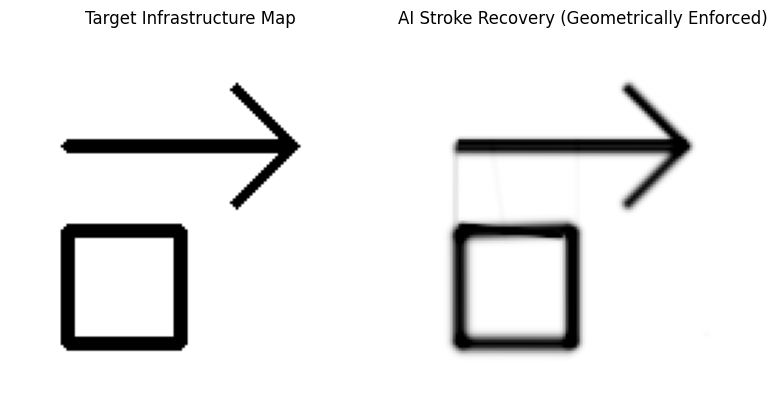


Final Stroke Opacities (Notice which ones dropped near 0.0):
[0.022 0.026 0.957 0.987 0.953 0.942 0.971 0.972 0.961 0.984 0.34  0.773
 0.978 0.121 0.025]


In [ ]:
with torch.no_grad():
    final_params = torch.sigmoid(raw_stroke_params)
    final_canvas = renderer.draw_lines(final_params, global_blur=end_blur).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target_tensor.cpu().numpy(), cmap='gray')
axes[0].set_title("Target Infrastructure Map")
axes[0].axis('off')

axes[1].imshow(final_canvas, cmap='gray')
axes[1].set_title(f"AI Stroke Recovery (Geometrically Enforced)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print Opacities to verify unused strokes were deleted
final_opacities = final_params[:, 5].detach().cpu().numpy()
print("\nFinal Stroke Opacities (Notice which ones dropped near 0.0):")
print(np.round(final_opacities, 3))